In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [16]:
demand = pd.read_excel("PGCB_date_power_demand.xlsx")

demand.columns = demand.columns.str.lower()

demand['datetime'] = pd.to_datetime(demand['datetime'])
demand = demand.sort_values('datetime')

# remove duplicates
demand = demand.drop_duplicates(subset=['datetime'])

# fill missing
demand = demand.ffill()

demand.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
24,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
22,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
21,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
20,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
19,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


In [17]:
# weather file has extra rows, so skip manually
weather = pd.read_excel("weather_data.xlsx", header=10)

weather.columns = weather.columns.str.lower()

# use first column as time
weather['datetime'] = pd.to_datetime(weather.iloc[:, 0], errors='coerce')

weather = weather.dropna(subset=['datetime'])
weather = weather.sort_values('datetime')

weather = weather.ffill()

weather.head()

,NaN,NaN,NaN,NaN,NaN,11.2.1,NaN,NaN,0.1,0.2,datetime
0,2014-01-01 07:00:00,11.6,96,10.8,0.0,11.0,14.3,325,0,0.0,2014-01-01 07:00:00
1,2014-01-01 08:00:00,13.9,92,14.0,0.0,12.5,15.5,328,0,3600.0,2014-01-01 08:00:00
2,2014-01-01 09:00:00,17.3,77,17.8,0.0,13.3,18.8,328,0,3600.0,2014-01-01 09:00:00
3,2014-01-01 10:00:00,20.0,67,20.6,0.0,13.6,21.4,323,0,3600.0,2014-01-01 10:00:00
4,2014-01-01 11:00:00,21.9,59,22.7,0.0,13.4,24.2,312,0,3600.0,2014-01-01 11:00:00


In [18]:
economic = pd.read_csv("economic_full_1.csv")

economic.columns = economic.columns.str.lower()

if 'year' not in economic.columns:
    economic['year'] = economic.iloc[:, 0]

economic['year'] = pd.to_numeric(economic['year'], errors='coerce')
economic = economic.dropna(subset=['year'])
economic['year'] = economic['year'].astype(int)

economic.head()

,country name,indicator name,indicator code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,year


In [19]:
df = pd.merge(demand, weather, on='datetime', how='left')

df['year'] = df['datetime'].dt.year.astype(int)

df = pd.merge(df, economic, on='year', how='left')

df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
z = (df['demand_mw'] - df['demand_mw'].mean()) / df['demand_mw'].std()

df.loc[np.abs(z) > 3, 'demand_mw'] = np.nan

df['demand_mw'] = df['demand_mw'].ffill()

In [21]:
# time features
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek

# lag features (simple)
df['lag_1'] = df['demand_mw'].shift(1)
df['lag_24'] = df['demand_mw'].shift(24)

# rolling mean
df['rolling_mean_24'] = df['demand_mw'].rolling(24).mean()

# target (next hour)
df['target'] = df['demand_mw'].shift(-1)

# clean data
df = df.dropna(subset=['target'])
df = df.ffill()

df = df.copy()  # remove warning

df.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,2022,2023,2024,2025,hour,dayofweek,lag_1,lag_24,rolling_mean_24,target
0,2015-04-19 00:00:00,4821.0,4821.0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,0,6,NaN,NaN,NaN,3612.0
1,2015-04-19 01:00:00,3612.0,3612.0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,1,6,4821.0,NaN,NaN,3727.0
2,2015-04-19 02:00:00,3727.0,3727.0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,2,6,3612.0,NaN,NaN,3632.0
3,2015-04-19 03:00:00,3632.0,3632.0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,3,6,3727.0,NaN,NaN,3641.0
4,2015-04-19 04:00:00,3641.0,3641.0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,4,6,3632.0,NaN,NaN,3283.0


In [22]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 73773
Test size: 18444


In [23]:

drop_cols = ['datetime', 'target', 'remarks','time']

X_train = train.drop(columns=drop_cols, errors='ignore')
X_test = test.drop(columns=drop_cols, errors='ignore')

# convert everything to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# fill missing
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# 🔥 VERY IMPORTANT (PUT AT VERY END)
X_train.columns = X_train.columns.map(str)
X_test.columns = X_test.columns.map(str)

y_train = train['target']
y_test = test['target']

# DEBUG (run once)
print(type(X_train.columns[0]))

<class 'str'>


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model used: Random Forest")

Model used: Random Forest


In [25]:
y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("MAPE:", round(mape, 2))

MAPE: 3.65


In [26]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,9754.0,10179.32
1,11283.0,10471.44
2,12409.0,11811.45
3,12242.0,12915.78
4,12699.0,12200.59
5,12662.0,12661.46
6,12690.0,12414.05
7,12568.0,12417.04
8,12110.0,12116.23
9,11500.0,12006.78


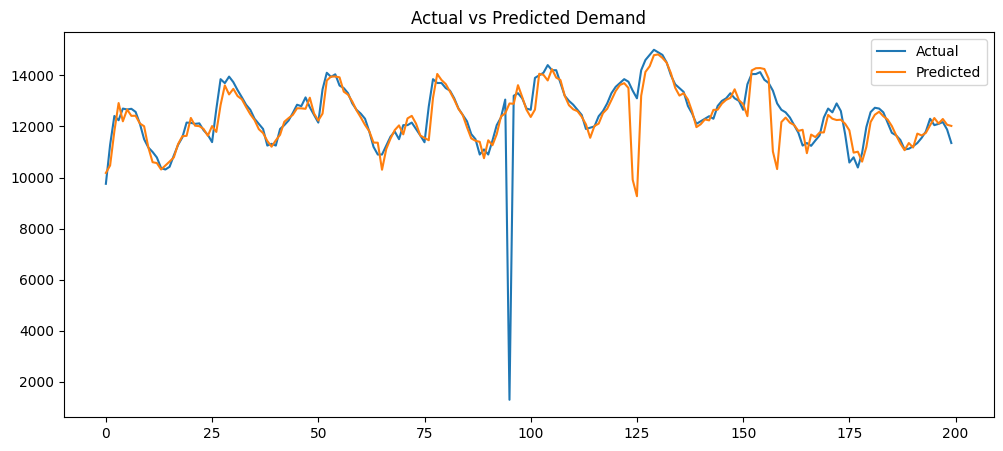

In [27]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Demand")

plt.show()

In [28]:
print(f"Test samples: {len(X_test)}")
print(f"MAPE: {mape:.2f}%")

Test samples: 18444
MAPE: 3.65%
